In [ ]:
# TODO: re-add linear velocity decision variable
# TODO: add uncertainty to parameters
# TODO: add uncertain disturbance forces
# TODO: add multi-objective optimization
# TODO: add off-limits position set - bounds
# TODO: add off-limits position set - obstacles

import grama as gr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

def vec_final_distance(control_vec):
    """
    Vectorized function to calculate the R (final distance from waypoint) column of a scenario row.
    """
    # grab deployment state
    state = deployment_state

    # iterate through control vector
    for wk in control_vec:
        # state variables
        xk, yk, thk = state

        # kinematics
        xk1 = xk + DT*V_LIN*math.cos(thk)
        yk1 = yk + DT*V_LIN*math.sin(thk)
        thk1 = thk + DT*wk

        # iterate state
        state = (xk1, yk1, thk1)
    
    # return raw distance from state to waypoint
    xf, yf, _ = state
    return np.sqrt((xf-waypt[0])**2 + (yf-waypt[1])**2)

def vec_total_distance(control_vec):
    """
    Vectorized function to calculate the D (total distance from waypoint across time) column of a scenario row.
    """
    # sum distance
    sum_distance = 0

    # grab deployment state
    state = deployment_state

    # iterate through control vector
    for wk in control_vec:
        # state variables
        xk, yk, thk = state

        # kinematics
        xk1 = xk + DT*V_LIN*math.cos(thk)
        yk1 = yk + DT*V_LIN*math.sin(thk)
        thk1 = thk + DT*wk

        # iterate state
        state = (xk1, yk1, thk1)

        # add to sum distance
        sum_distance += np.sqrt((xk1-waypt[0])**2 + (yk1-waypt[1])**2)
    
    # return raw distance from state to waypoint
    return sum_distance

def vec_final_energy(control_vec):
    """
    Vectorized function to calculate the J (final energy) column of a scenario row.
    """
    # relative energy consumption
    relative_energy = 0.0

    # iterate through control vector
    for wk in control_vec:
        relative_energy += wk**2
    
    # return total relative energy
    return relative_energy

def model_trajectory(df_in: pd.DataFrame):
    """
    DataFrame-based method of extracting objective function values from a given control input sequence.

    Args:
        df_in: A DataFrame in which each column represents an angular velocity at a specific timestep.

    Returns:
        df_out: A DataFrame in which each column represents an objective function value.

    example:
        gr.cp_vec_function(
            fun=lambda df: gr.df_make(y=1 + 0.5 * df.x),
            var=["x"],
            out=["y"],
            name="Simple linear function",
        )
    """
    # establish the out dataframe
    df_out = pd.DataFrame()
    
    # establish vectorized functions for objectives
    df_out["R"] = df_in.apply(vec_final_distance,axis="columns",raw=True,)
    df_out["D"] = df_in.apply(vec_total_distance,axis="columns",raw=True,)
    df_out["J"] = df_in.apply(vec_final_energy,axis="columns",raw=True,)

    # return
    return df_out


# parameters
timesteps = 10 # num. steps
deployment_state = (0.0, 0.0, math.pi/4) # x, y, theta
waypt = (2.5, 2.5) # x, y

# constants
DT = 1.0 # sec
V_LIN = 0.5 # m/s
W_MAX = 3.0 # rad/s

# grama variable vectors
ang_vels = [f"w{k}" for k in range(timesteps)]
objectives = ["J", "R", "D"]
states = [f"x{k}" for k in range(timesteps)]

# define model
md_asv = (
    # initial model
    gr.Model()
    # state transition kinematics
    >> gr.cp_vec_function(
        fun=model_trajectory,
        var=ang_vels,
        out=objectives,
    )
    # constraints on angular velocity
    >> gr.cp_bounds(
        **{f"w{k}": (-W_MAX, +W_MAX) for k in range(timesteps)}
    )
)

md_asv.printpretty()

model: (no name)

  inputs:
    var_det:
      w5: [-3.0, 3.0]
      w0: [-3.0, 3.0]
      w4: [-3.0, 3.0]
      w7: [-3.0, 3.0]
      w2: [-3.0, 3.0]
      w6: [-3.0, 3.0]
      w9: [-3.0, 3.0]
      w3: [-3.0, 3.0]
      w1: [-3.0, 3.0]
      w8: [-3.0, 3.0]

    var_rand:

    copula:
      None

  functions:
      f0: ['w0', 'w1', 'w2', 'w3', 'w4', 'w5', 'w6', 'w7', 'w8', 'w9'] -> ['J', 'R', 'D']



In [80]:

df_test: pd.DataFrame = (
    md_asv
    >> gr.ev_min(
        out_min="D",
        n_restart=20,
    )
)

pop_count = 5
optimal_run = []
control_opt = []
opt_val = []
for i in range(pop_count):
    optimal_run.append(df_test.loc[df_test["D"].idxmin()])
    control_opt.append(optimal_run[-1][ang_vels])
    opt_val.append(optimal_run[-1]["D"])

Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec


/home/ivymahncke/miniconda3/envs/pdo/lib/python3.9/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
/home/ivymahncke/miniconda3/envs/pdo/lib/python3.9/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds


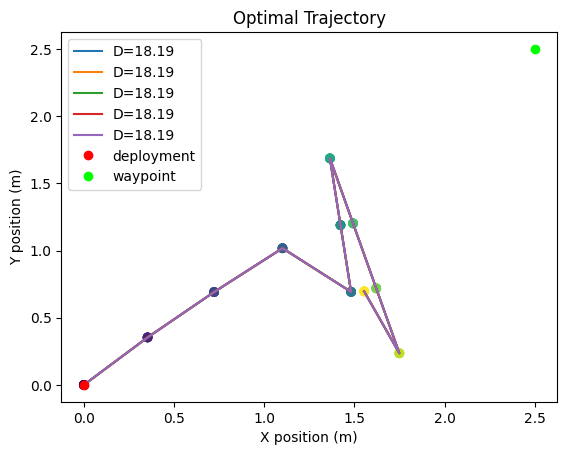

In [81]:
def plot_trajectory(control_vec,opt_val,deployment_state,):
    """
    """
    # for plotting
    x_vec = []
    y_vec = []
    # grab deployment state
    state = deployment_state

    # iterate through control vector
    for wk in control_vec:
        # state variables
        xk, yk, thk = state
        x_vec.append(xk)
        y_vec.append(yk)

        # kinematics
        xk1 = xk + DT*V_LIN*math.cos(thk)
        yk1 = yk + DT*V_LIN*math.sin(thk)
        thk1 = thk + DT*wk

        # iterate state
        state = (xk1, yk1, thk1)

    # add final states
    x_vec+=[xk1]
    y_vec+=[yk1]

    # plot
    plt.plot(x_vec, y_vec,label=f"D={round(opt_val,2)}")
    plt.scatter(x_vec, y_vec,c=np.linspace(0, 1, len(x_vec)))

for vec, opt in zip(control_opt, opt_val):
    plot_trajectory(
        vec,
        opt,
        deployment_state,
    )

plt.plot(deployment_state[0],deployment_state[1],"o",label="deployment",color="red")
plt.plot(waypt[0],waypt[1],"o",label="waypoint",color="lime")
plt.xlabel("X position (m)")
plt.ylabel("Y position (m)")
plt.title("Optimal Trajectory")
plt.legend(loc="upper left")
plt.show()


In [56]:
df_vec = df_test.loc[df_test["D"].idxmin()]
print(f"py-grama optimal outcome:\n{df_vec}")
print(f"optimal ang vels:\n{df_vec[ang_vels]}")
print(f"as ndarray: {df_vec[ang_vels].to_numpy()}")

py-grama optimal outcome:
w4                                    -0.000101
w7                                       0.0013
w6                                    -0.001641
w9                                     0.000096
w1                                    -0.000163
w8                                    -0.000706
w5                                     0.003143
w0                                    -0.001757
w2                                    -0.000729
w3                                    -0.225207
w4_0                                  -0.421739
w7_0                                  -0.838232
w6_0                                  -0.474563
w9_0                                  -0.768728
w1_0                                  -0.994949
w8_0                                   0.437141
w5_0                                  -0.405926
w0_0                                  -0.989092
w2_0                                   0.335813
w3_0                                  -0.225207
R             